In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")

In [2]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    "exports/clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    "exports/clean_cash_flow.csv"
)

analysis = pd.read_csv(
    "exports/clean_analysis.csv"
)

In [3]:
print(profit_loss.shape)
print(balance_sheet.shape)
print(cash_flow.shape)
print(analysis.shape)

(1276, 18)
(1312, 15)
(1187, 7)
(20, 6)


In [4]:
merged = profit_loss.merge(
    balance_sheet[
        [
            "company_id",
            "year",
            "borrowings"
        ]
    ],
    on=["company_id", "year"],
    how="left"
)

In [5]:
features = merged[
    [
        "company_id",
        "year",
        "sales",
        "net_profit",
        "operating_profit",
        "borrowings"
    ]
]

In [7]:
features = features.fillna(0)

In [8]:
features.head()

,company_id,year,sales,net_profit,operating_profit,borrowings
0,ABB,Dec 2012,1653,145,202.0,0.0
1,ABB,Mar 2014,2276,198,267.0,0.0
2,ABB,Mar 2015,2289,229,312.0,0.0
3,ABB,Mar 2016,2614,255,365.0,0.0
4,ABB,Mar 2017,2903,277,398.0,0.0


In [9]:
numeric_cols = [
    "sales",
    "net_profit",
    "operating_profit",
    "borrowings"
]

In [10]:
z_scores = features[numeric_cols].apply(zscore)

In [11]:
features["z_anomaly"] = (
    (np.abs(z_scores) > 3)
    .any(axis=1)
)

In [12]:
z_anomalies = features[
    features["z_anomaly"] == True
]

z_anomalies.head(20)

,company_id,year,sales,net_profit,operating_profit,borrowings,z_anomaly
165,AXISBANK,Mar 2020,62635,1627,35066.0,797337.0,True
166,AXISBANK,Mar 2021,63346,6588,31749.0,850551.0,True
167,AXISBANK,Mar 2022,67377,13025,29962.0,1020943.0,True
168,AXISBANK,Mar 2023,85164,9580,29089.0,1152038.0,True
169,AXISBANK,Mar 2024,109369,24861,37943.0,1295302.0,True
215,BANKBARODA,Mar 2020,78895,981,40583.0,1068981.0,True
216,BANKBARODA,Mar 2021,74314,1620,38070.0,1067173.0,True
217,BANKBARODA,Mar 2022,73385,7933,37518.0,1185331.0,True
218,BANKBARODA,Mar 2023,94503,15005,38231.0,1342592.0,True
219,BANKBARODA,Mar 2024,118379,18869,44379.0,1453761.0,True


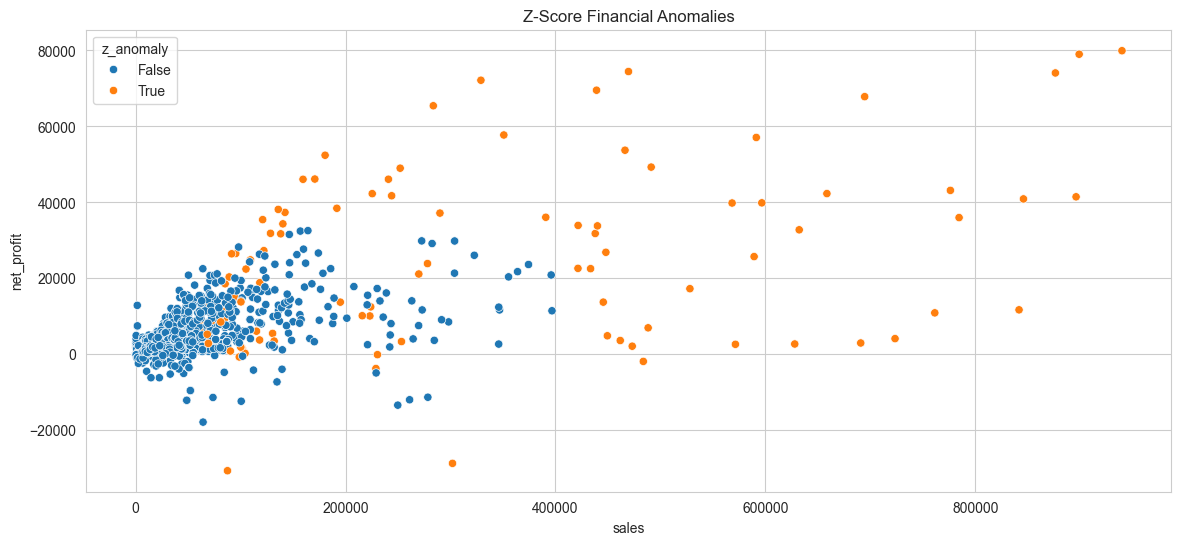

In [13]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=features,
    x="sales",
    y="net_profit",
    hue="z_anomaly"
)

plt.title("Z-Score Financial Anomalies")

plt.show()

In [14]:
X = features[
    [
        "sales",
        "net_profit",
        "operating_profit",
        "borrowings"
    ]
]

In [15]:
iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

features["iforest_flag"] = iso.fit_predict(X)

In [16]:
features["iforest_flag"] = (
    features["iforest_flag"]
    .map({1:0, -1:1})
)

In [17]:
ml_anomalies = features[
    features["iforest_flag"] == 1
]

ml_anomalies.head(20)

,company_id,year,sales,net_profit,operating_profit,borrowings,z_anomaly,iforest_flag
169,AXISBANK,Mar 2024,109369,24861,37943.0,1295302.0,True,1
218,BANKBARODA,Mar 2023,94503,15005,38231.0,1342592.0,True,1
219,BANKBARODA,Mar 2024,118379,18869,44379.0,1453761.0,True,1
310,CANBK,Mar 2024,110519,15401,46146.0,1369780.0,True,1
514,HDFCBANK,Mar 2020,122189,27296,45459.0,1333041.0,True,1
515,HDFCBANK,Mar 2021,128552,31857,52457.0,1511418.0,True,1
516,HDFCBANK,Mar 2022,135936,38151,56557.0,1784970.0,True,1
517,HDFCBANK,Mar 2023,170754,46149,63042.0,2139212.0,True,1
518,HDFCBANK,Mar 2024,283649,65446,174196.0,3107503.0,True,1
519,HDFCBANK,TTM,329022,72168,206009.0,0.0,True,1


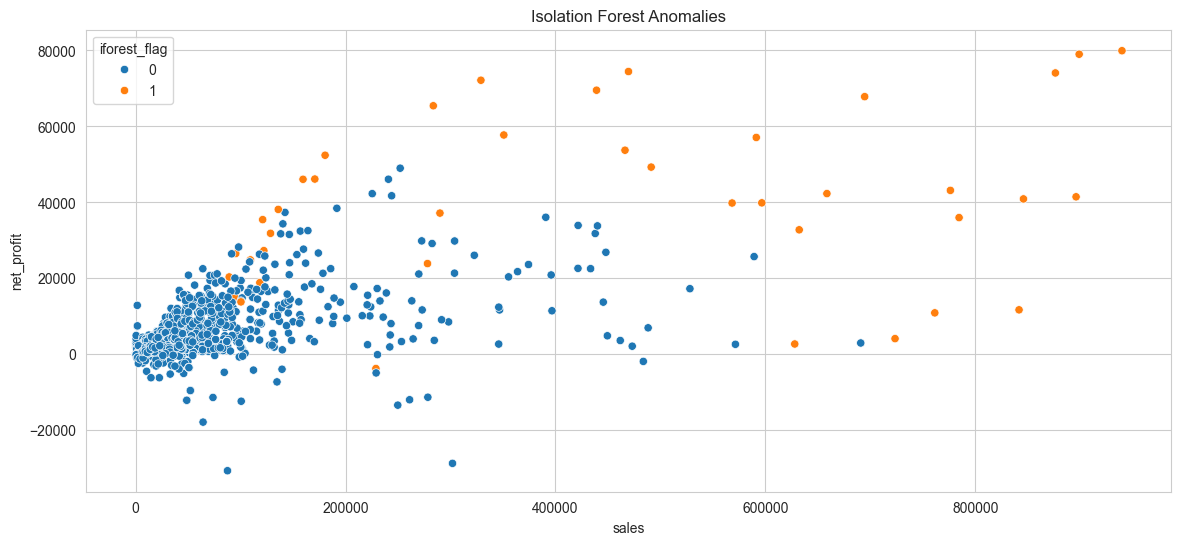

In [18]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=features,
    x="sales",
    y="net_profit",
    hue="iforest_flag"
)

plt.title("Isolation Forest Anomalies")

plt.show()

In [19]:
company_anomalies = (
    features.groupby("company_id")["iforest_flag"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

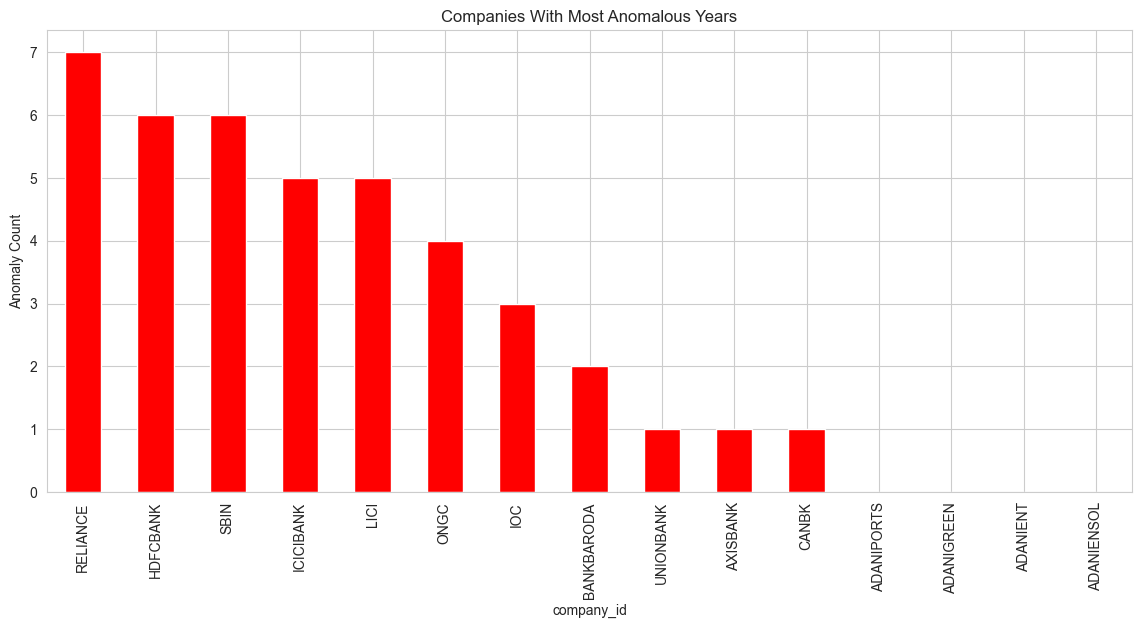

In [20]:
company_anomalies.plot(
    kind="bar",
    figsize=(14,6),
    color="red"
)

plt.title("Companies With Most Anomalous Years")

plt.ylabel("Anomaly Count")

plt.show()

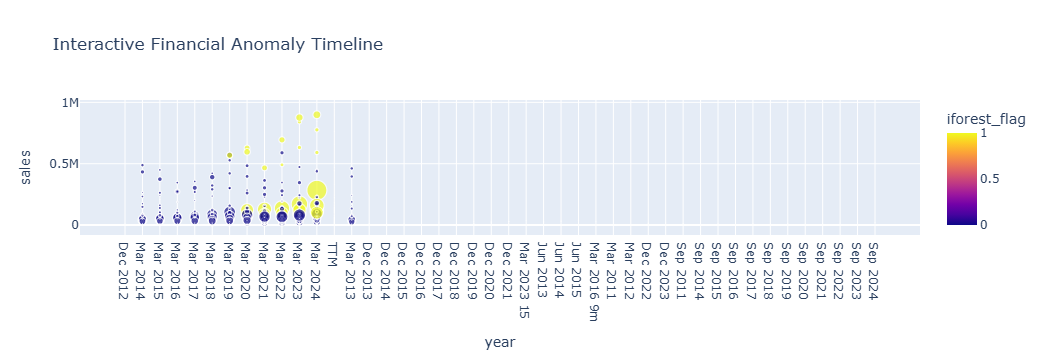

In [21]:
fig = px.scatter(
    features,
    x="year",
    y="sales",
    color="iforest_flag",
    hover_name="company_id",
    size="borrowings",
    title="Interactive Financial Anomaly Timeline"
)

fig.show()

In [22]:
covid = features[
    features["year"]
    .astype(str)
    .str.contains("2020")
]

In [23]:
covid.head()

,company_id,year,sales,net_profit,operating_profit,borrowings,z_anomaly,iforest_flag
7,ABB,Mar 2020,4093,593,757.0,175.0,False,0
19,ADANIENSOL,Mar 2020,11416,706,4258.0,24246.0,False,0
32,ADANIENT,Mar 2020,43403,1040,2294.0,12419.0,False,0
41,ADANIGREEN,Mar 2020,2549,-68,1450.0,14866.0,False,0
54,ADANIPORTS,Mar 2020,11873,3785,5947.0,30242.0,False,0


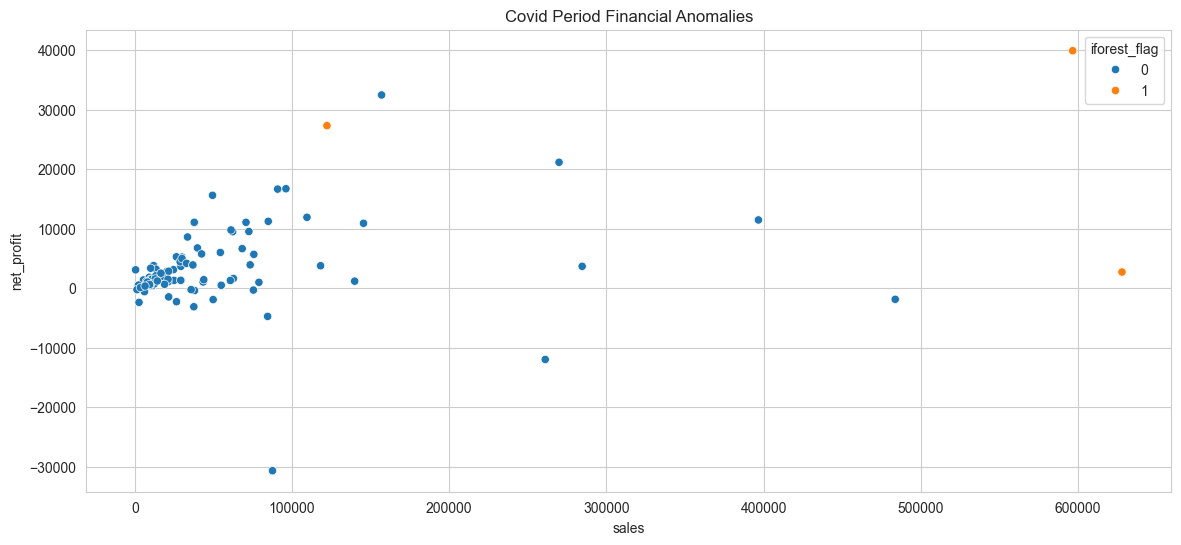

In [24]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=covid,
    x="sales",
    y="net_profit",
    hue="iforest_flag"
)

plt.title("Covid Period Financial Anomalies")

plt.show()

In [25]:
adani = features[
    features["company_id"]
    .str.contains("ADANI", na=False)
]

In [26]:
adani.head()

,company_id,year,sales,net_profit,operating_profit,borrowings,z_anomaly,iforest_flag
13,ADANIENSOL,Mar 2014,0,0,0.0,0.0,False,0
14,ADANIENSOL,Mar 2015,131,-7,101.0,9701.0,False,0
15,ADANIENSOL,Mar 2016,2194,368,1927.0,8585.0,False,0
16,ADANIENSOL,Mar 2017,2876,416,1983.0,8975.0,False,0
17,ADANIENSOL,Mar 2018,3944,1143,2826.0,10428.0,False,0


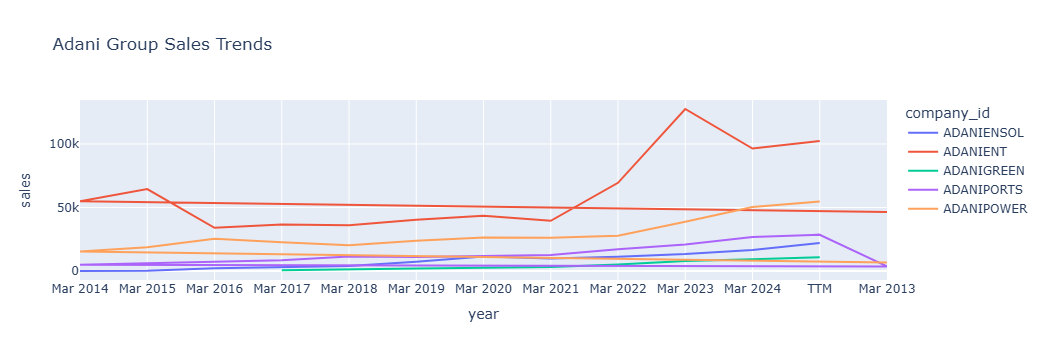

In [27]:
fig = px.line(
    adani,
    x="year",
    y="sales",
    color="company_id",
    title="Adani Group Sales Trends"
)

fig.show()

In [28]:
comparison = pd.crosstab(
    features["z_anomaly"],
    features["iforest_flag"]
)

comparison

iforest_flag,0,1
z_anomaly,,
False,1256,0
True,63,41


In [29]:
features.to_csv(
    "exports/anomaly_flags.csv",
    index=False
)

In [30]:
import os

os.listdir("exports")

['anomaly_flags.csv',
 'clean_analysis.csv',
 'clean_balance_sheet.csv',
 'clean_cash_flow.csv',
 'clean_profit_loss.csv',
 'company_health_scores.csv',
 'sales_growth.csv']